In [2]:
%pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

  Using cached tensorflow-2.20.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (4.5 kB)
  Using cached pandas-3.0.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl

In [3]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install tensorflow-macos tensorflow-metal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew #for some statistics

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder # OneHotEncoder is implicitly handled by pd.get_dummies
from sklearn.metrics import mean_squared_error

# Models
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.linear_model import Lasso, LassoCV

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # Format floats to 3 decimal places
sns.set_style('darkgrid') # Seaborn style

# --- Data Loading ---
# Attempt to load the datasets.
# Replace 'train.csv' and 'test.csv' with the actual paths to your files if they are in a different directory.
try:
    #train_df_original = pd.read_csv('train.csv')
    #test_df_original = pd.read_csv('test.csv')
    
    train_df_original = pd.read_csv("/Users/krishna/dev/pyenv/housePriceData/train.csv")
    test_df_original = pd.read_csv("/Users/krishna/dev/pyenv/housePriceData/test.csv")

    print("Successfully loaded train.csv and test.csv")
except FileNotFoundError:
    print("Warning: 'train.csv' or 'test.csv' not found in the current directory.")
    print("Using dummy data for demonstration purposes. Replace with your actual data.")
    # Create dummy data if actual files are not found (for demonstration)
    dummy_train_data = {
        'Id': range(1, 1461),
        'MSSubClass': np.random.choice([20, 50, 60, 70, 120], size=1460),
        'MSZoning': np.random.choice(['RL', 'RM', 'FV', 'RH'], size=1460),
        'LotFrontage': np.random.normal(70, 20, 1460),
        'LotArea': np.random.normal(10000, 3000, 1460),
        'OverallQual': np.random.randint(1, 11, 1460),
        'OverallCond': np.random.randint(1, 10, 1460),
        'YearBuilt': np.random.randint(1870, 2011, 1460),
        'YearRemodAdd': np.random.randint(1950, 2011, 1460),
        'MasVnrArea': np.random.normal(100, 150, 1460),
        'TotalBsmtSF': np.random.normal(1000, 400, 1460),
        'GrLivArea': np.random.normal(1500, 500, 1460),
        'FullBath': np.random.randint(0, 4, 1460),
        'BedroomAbvGr': np.random.randint(0, 6, 1460),
        'KitchenQual': np.random.choice(['Ex', 'Gd', 'TA', 'Fa'], size=1460),
        'TotRmsAbvGrd': np.random.randint(2, 13, 1460),
        'GarageCars': np.random.randint(0, 5, 1460),
        'GarageArea': np.random.normal(450, 200, 1460),
        'PoolArea': np.random.choice([0, 0, 0, 0, 0, 500, 600], size=1460),
        'SalePrice': np.random.normal(180000, 70000, 1460)
    }
    dummy_test_data = {col: dummy_train_data[col][:1000] for col in dummy_train_data if col != 'SalePrice'} # Test data subset
    dummy_test_data['Id'] = range(1461, 1461 + 1000)


    train_df_original = pd.DataFrame(dummy_train_data)
    test_df_original = pd.DataFrame(dummy_test_data)
    # Ensure positive prices and areas for dummy data
    train_df_original['SalePrice'] = train_df_original['SalePrice'].clip(lower=10000)
    for col in ['LotFrontage', 'LotArea', 'MasVnrArea', 'TotalBsmtSF', 'GrLivArea', 'GarageArea']:
        train_df_original[col] = train_df_original[col].clip(lower=0)
        if col in test_df_original.columns:
             test_df_original[col] = test_df_original[col].clip(lower=0)


# Make copies to preserve original data
train_df = train_df_original.copy()
test_df = test_df_original.copy()

print(f"\nTrain data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

# Store IDs for final submission
train_id = train_df['Id']
test_id = test_df['Id']

# Drop Id column as it's not a predictive feature for training
train_df = train_df.drop('Id', axis=1)
test_df = test_df.drop('Id', axis=1)

print("\nFirst 5 rows of training data:")
print(train_df.head())


ModuleNotFoundError: No module named 'xgboost'


--- 2. Data Exploration (EDA) ---

Analyzing the target variable: SalePrice
Original SalePrice: Skewness = 1.88, Kurtosis = 6.54
Original SalePrice: Fitted Normal Dist. Mean (mu) = 180921.20, Std (sigma) = 79415.29
Log-Transformed SalePrice: Skewness = 0.12, Kurtosis = 0.81
Log-Transformed SalePrice: Fitted Normal Dist. Mean (mu) = 12.02, Std (sigma) = 0.40


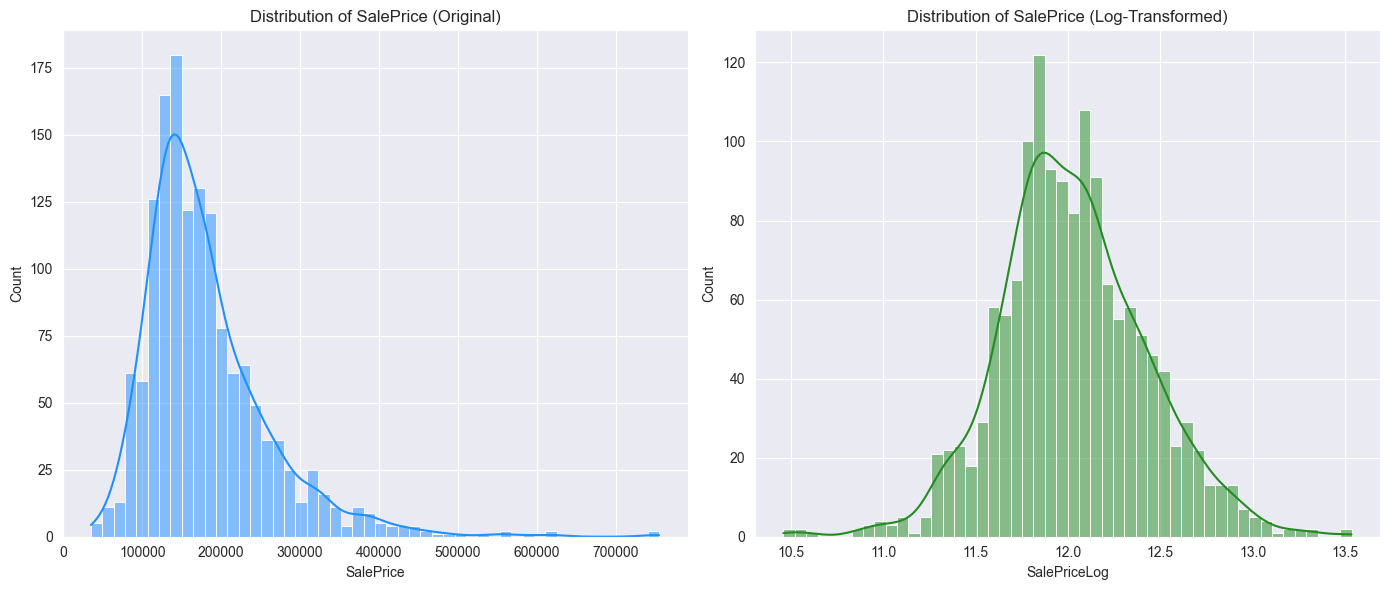


Analyzing numerical features...


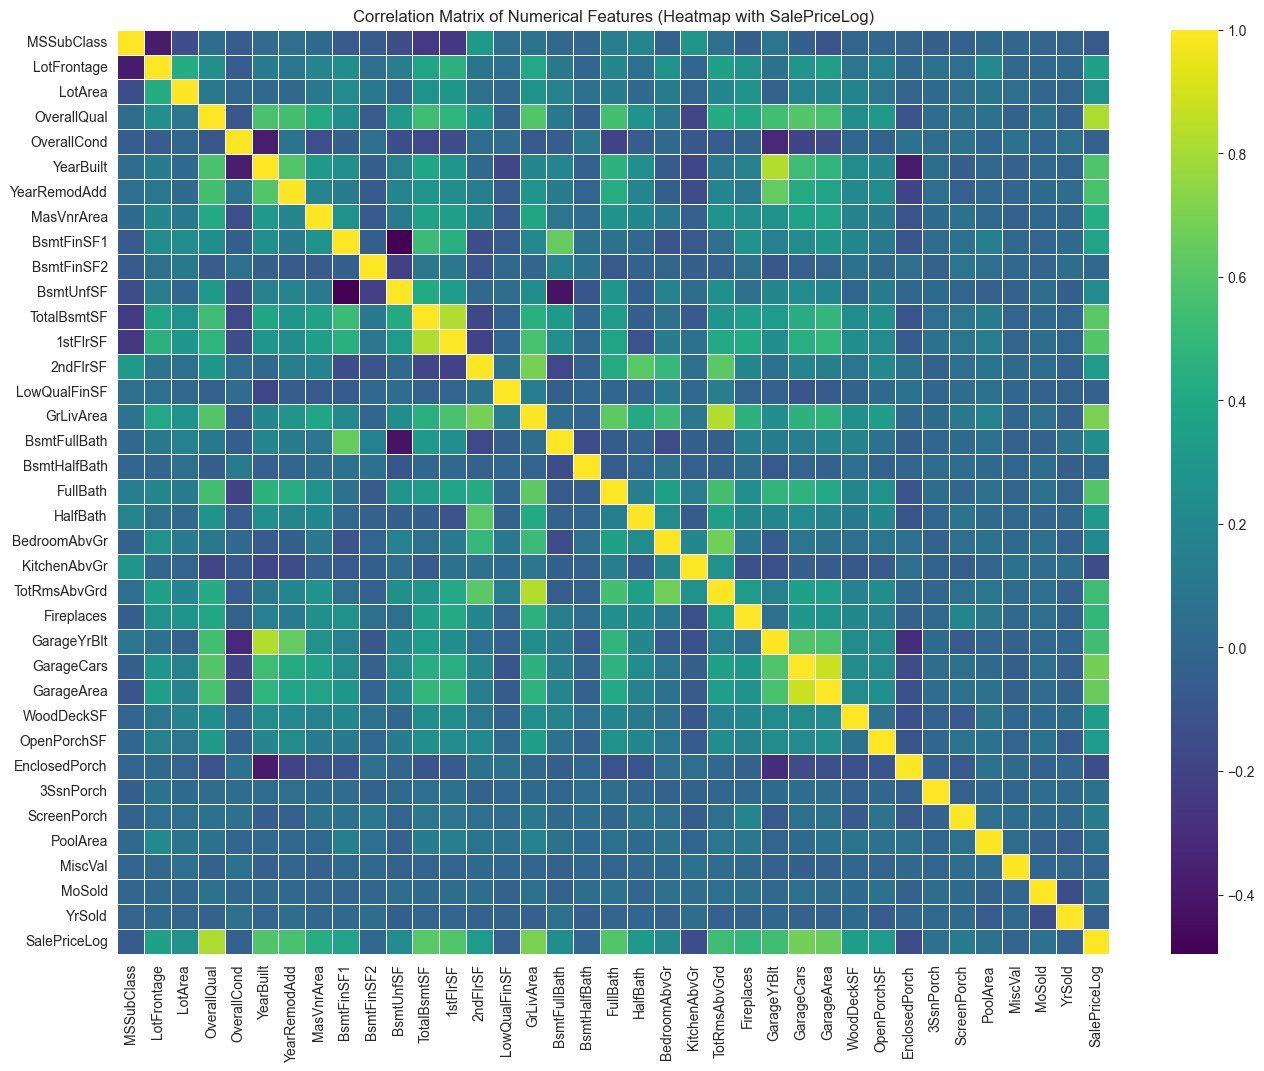


Top 10 features most positively correlated with SalePriceLog:
SalePriceLog   1.000
OverallQual    0.817
GrLivArea      0.701
GarageCars     0.681
GarageArea     0.651
TotalBsmtSF    0.612
1stFlrSF       0.597
FullBath       0.595
YearBuilt      0.587
YearRemodAdd   0.566
GarageYrBlt    0.541
Name: SalePriceLog, dtype: float64

Top 5 features most negatively correlated with SalePriceLog:
EnclosedPorch   -0.149
KitchenAbvGr    -0.148
MSSubClass      -0.074
LowQualFinSF    -0.038
YrSold          -0.037
Name: SalePriceLog, dtype: float64

Analyzing categorical features...
Found 43 categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']...

Analyzing missing values in the training set...
Summary of features with missing values (Train Set):
              Total Missing  Percent Missing Data Type
PoolQC                 1453           99.521    object
MiscFeature            1406           96.301    object
Alley                  1369           93.767    object
Fence     

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew

# This code block assumes 'train_df' is loaded and available from the previous step (1. Project Setup & Data Loading).
# It should contain features and the 'SalePrice' target variable.
# If running this block independently, ensure 'train_df' is loaded appropriately.

if 'train_df' not in globals():
    print("train_df not found. Please run the '1. Project Setup & Data Loading' block first or load your data.")
    # As a fallback for standalone execution, create a minimal dummy train_df
    dummy_train_data_eda = {
        'OverallQual': np.random.randint(1, 11, 100),
        'GrLivArea': np.random.normal(1500, 500, 100).clip(lower=300),
        'GarageCars': np.random.randint(0, 5, 100),
        'TotalBsmtSF': np.random.normal(1000, 400, 100).clip(lower=0),
        'FullBath': np.random.randint(0, 4, 100),
        'YearBuilt': np.random.randint(1870, 2011, 100),
        'Neighborhood': np.random.choice(['OldTown', 'Edwards', 'CollgCr', 'NAmes', 'Somerst'], size=100),
        'KitchenQual': np.random.choice(['Ex', 'Gd', 'TA', 'Fa'], size=100),
        'SalePrice': np.random.normal(180000, 70000, 100).clip(lower=30000)
    }
    train_df = pd.DataFrame(dummy_train_data_eda)
    print("Using a minimal dummy train_df for EDA demonstration.")


print("\n--- 2. Data Exploration (EDA) ---")

# --- 2.1 Target Variable Analysis ('SalePrice') ---
if 'SalePrice' in train_df.columns:
    print("\nAnalyzing the target variable: SalePrice")
    plt.figure(figsize=(14, 6))

    # Plot 1: Distribution of SalePrice
    plt.subplot(1, 2, 1)
    sns.histplot(train_df['SalePrice'], kde=True, color="dodgerblue", bins=50)
    plt.title('Distribution of SalePrice (Original)')
    mu_original, sigma_original = norm.fit(train_df['SalePrice']) # Fit a normal distribution
    print(f"Original SalePrice: Skewness = {train_df['SalePrice'].skew():.2f}, Kurtosis = {train_df['SalePrice'].kurtosis():.2f}")
    print(f"Original SalePrice: Fitted Normal Dist. Mean (mu) = {mu_original:.2f}, Std (sigma) = {sigma_original:.2f}")


    # Log transform SalePrice to handle positive skewness (common for monetary values)
    # np.log1p applies log(1+x) which handles potential zero values safely (though prices are usually >0)
    train_df['SalePriceLog'] = np.log1p(train_df['SalePrice'])
    # Store this globally as it's the target we'll predict for most models
    y_train_log_global = train_df['SalePriceLog'].copy() 

    # Plot 2: Distribution of Log-Transformed SalePrice
    plt.subplot(1, 2, 2)
    sns.histplot(train_df['SalePriceLog'], kde=True, color="forestgreen", bins=50)
    plt.title('Distribution of SalePrice (Log-Transformed)')
    mu_log, sigma_log = norm.fit(train_df['SalePriceLog']) # Fit a normal distribution
    print(f"Log-Transformed SalePrice: Skewness = {train_df['SalePriceLog'].skew():.2f}, Kurtosis = {train_df['SalePriceLog'].kurtosis():.2f}")
    print(f"Log-Transformed SalePrice: Fitted Normal Dist. Mean (mu) = {mu_log:.2f}, Std (sigma) = {sigma_log:.2f}")
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'SalePrice' column not found in train_df. Cannot perform target variable analysis.")
    # Create a dummy y_train_log_global if SalePrice is not there for subsequent code blocks to run
    y_train_log_global = pd.Series(np.random.normal(12, 0.5, len(train_df)))


# --- 2.2 Numerical Feature Analysis ---
print("\nAnalyzing numerical features...")
numerical_cols = train_df.select_dtypes(include=np.number).columns.tolist()
# Exclude SalePrice (original) if SalePriceLog (transformed target) exists for correlation analysis
if 'SalePriceLog' in numerical_cols:
    numerical_cols_for_corr = [col for col in numerical_cols if col != 'SalePrice']
    target_for_corr = 'SalePriceLog'
elif 'SalePrice' in numerical_cols: # Fallback if SalePriceLog wasn't created
    numerical_cols_for_corr = numerical_cols
    target_for_corr = 'SalePrice'
else:
    numerical_cols_for_corr = []
    target_for_corr = None
    print("No target variable (SalePrice or SalePriceLog) found for numerical feature correlation.")

if target_for_corr:
    # Correlation matrix heatmap
    correlation_matrix = train_df[numerical_cols_for_corr].corr()
    plt.figure(figsize=(16, 12))
    sns.heatmap(correlation_matrix, annot=False, cmap='viridis', fmt=".1f", linewidths=.5, cbar=True)
    plt.title(f'Correlation Matrix of Numerical Features (Heatmap with {target_for_corr})')
    plt.show()

    # Top features correlated with the target variable
    if target_for_corr in correlation_matrix.columns:
        print(f"\nTop 10 features most positively correlated with {target_for_corr}:")
        print(correlation_matrix[target_for_corr].sort_values(ascending=False).head(11)) # Top 10 + target itself
        
        print(f"\nTop 5 features most negatively correlated with {target_for_corr}:")
        print(correlation_matrix[target_for_corr].sort_values(ascending=True).head(5))

        # Scatter plots for some highly correlated features vs. the target
        # Example: 'OverallQual', 'GrLivArea' (Adapt based on your dataset's top correlations)
        # top_positive_corr_features = correlation_matrix[target_for_corr].sort_values(ascending=False).index[1:4] # Top 3 positive
        # for col in top_positive_corr_features:
        #     if col in train_df.columns:
        #         plt.figure(figsize=(8, 5))
        #         sns.scatterplot(x=train_df[col], y=train_df[target_for_corr])
        #         plt.title(f'{col} vs {target_for_corr}')
        #         plt.xlabel(col)
        #         plt.ylabel(target_for_corr)
        #         plt.grid(True)
        #         plt.show()
    else:
        print(f"Target variable '{target_for_corr}' not found in correlation matrix columns after filtering.")


# --- 2.3 Categorical Feature Analysis ---
print("\nAnalyzing categorical features...")
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()
print(f"Found {len(categorical_cols)} categorical columns: {categorical_cols[:5]}...") # Print first 5

# Example: Box plots for a few categorical features vs. the log-transformed target
# This helps visualize how different categories relate to house prices.
# for col in ['Neighborhood', 'KitchenQual', 'MSZoning', 'ExterQual']: # Choose some prominent categoricals
#     if col in train_df.columns and target_for_corr and target_for_corr in train_df.columns:
#         plt.figure(figsize=(12, 7) if train_df[col].nunique() > 10 else (8,5) )
#         # Order categories by median SalePriceLog for better visualization
#         order = train_df.groupby(col)[target_for_corr].median().sort_values().index
#         sns.boxplot(x=train_df[col], y=train_df[target_for_corr], order=order, palette="Set3")
#         plt.title(f'{col} vs {target_for_corr}')
#         plt.xlabel(col)
#         plt.ylabel(target_for_corr)
#         plt.xticks(rotation=45, ha='right' if train_df[col].nunique() > 5 else 'center')
#         plt.tight_layout()
#         plt.grid(axis='y')
#         plt.show()


# --- 2.4 Missing Values Analysis ---
print("\nAnalyzing missing values in the training set...")
missing_values_total = train_df.isnull().sum()
missing_values_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_data_summary = pd.DataFrame({
    'Total Missing': missing_values_total,
    'Percent Missing': missing_values_percent,
    'Data Type': train_df.dtypes
})
missing_data_summary = missing_data_summary[missing_data_summary['Total Missing'] > 0].sort_values(by='Percent Missing', ascending=False)
print("Summary of features with missing values (Train Set):")
if not missing_data_summary.empty:
    print(missing_data_summary.head(20)) # Display top 20 features with missing values
    # plt.figure(figsize=(10,6))
    # missing_data_summary['Percent Missing'].plot(kind='bar')
    # plt.title('Percentage of Missing Values by Feature (Train Set)')
    # plt.ylabel('Percentage Missing (%)')
    # plt.xticks(rotation=45, ha='right')
    # plt.tight_layout()
    # plt.show()
else:
    print("No missing values found in the training set.")


# --- 2.5 Outlier Detection (Example for GrLivArea) ---
# Outliers can significantly affect regression models, especially linear ones.
# if 'GrLivArea' in train_df.columns and target_for_corr and target_for_corr in train_df.columns:
#     print("\nChecking for outliers using GrLivArea vs SalePriceLog...")
#     plt.figure(figsize=(10,6))
#     sns.scatterplot(x=train_df['GrLivArea'], y=train_df[target_for_corr], alpha=0.6)
#     plt.title('GrLivArea vs SalePriceLog (Potential Outliers)')
#     plt.xlabel('Above Grade Living Area (sq ft)')
#     plt.ylabel(target_for_corr)
#     plt.grid(True)
#     plt.show()
    
    # Example of identifying and potentially removing outliers (common in Ames dataset)
    # In the Ames dataset, there are a few data points with very large GrLivArea but unusually low SalePrice.
    # These are often considered outliers and removed.
    # Condition for outlier removal (example):
    # outliers_condition = (train_df['GrLivArea'] > 4000) & (train_df[target_for_corr] < 12.5) # Adjust thresholds as needed
    # outliers_to_remove = train_df[outliers_condition].index
    # if not outliers_to_remove.empty:
    #     print(f"Identified {len(outliers_to_remove)} potential outliers to remove based on GrLivArea and SalePriceLog.")
    #     # train_df = train_df.drop(outliers_to_remove)
    #     # y_train_log_global = y_train_log_global.drop(outliers_to_remove) # Ensure target is also updated
    #     # print(f"Removed outliers. New train_df shape: {train_df.shape}")
    # else:
    #     print("No extreme outliers found matching the example GrLivArea condition.")

print("\nEDA Concluded. Review the plots and summaries to inform the next steps: Pre-processing and Feature Engineering.")


In [3]:
import pandas as pd
import numpy as np

# This code block assumes 'train_df', 'test_df', and 'y_train_log_global' are available
# from the previous EDA and Data Loading steps.
# 'train_df' here should be the version potentially modified by outlier removal in EDA,
# and 'y_train_log_global' should correspond to it.

if 'train_df' not in globals() or 'test_df' not in globals() or 'y_train_log_global' not in globals():
    print("train_df, test_df, or y_train_log_global not found. Please run preceding blocks or load your data.")
    # Fallback: Create minimal dummy data for this block to run
    n_train, n_test = 100, 50
    train_data_prep = {
        'Id': range(1, n_train + 1), 'MSSubClass': [60]* (n_train//2) + [20]*(n_train//2),
        'MSZoning': ['RL'] * n_train, 'LotFrontage': np.random.normal(70, 10, n_train),
        'Alley': [np.nan]*(n_train-10) + ['Grvl']*10, 'OverallQual': np.random.randint(5,9,n_train),
        'YearBuilt': np.random.randint(1950,2010,n_train),
        'BsmtQual': [np.nan]*5 + ['Gd']*(n_train//2-5) + ['TA']*(n_train//2),
        'GarageType': ['Attchd']*(n_train-5) + [np.nan]*5,
        'GarageYrBlt': np.random.randint(1950,2010,n_train),
        'SalePrice': np.random.normal(180000,20000,n_train)
    }
    train_data_prep['LotFrontage'][0:5] = np.nan # Introduce NaNs
    train_data_prep['GarageYrBlt'][5:10] = np.nan
    
    train_df_original_prep = pd.DataFrame(train_data_prep)
    if 'Id' in train_df_original_prep.columns:
         train_df_original_prep = train_df_original_prep.drop('Id', axis=1) # Id usually dropped

    # Create y_train_log_global from this dummy data
    y_train_log_global = np.log1p(train_df_original_prep['SalePrice'])
    train_df = train_df_original_prep.drop(columns=['SalePrice', 'SalePriceLog'], errors='ignore') # Keep only features

    test_data_prep = {col: val[:n_test] for col, val in train_data_prep.items() if col not in ['Id', 'SalePrice']}
    test_df = pd.DataFrame(test_data_prep)
    print("Using minimal dummy data for Pre-processing demonstration.")


print("\n--- 3. Data Pre-processing ---")

# --- 3.1 Combine Train and Test Data for Consistent Pre-processing ---
# Store number of rows in train and test sets to split them back later
ntrain = train_df.shape[0]
ntest = test_df.shape[0]

# The target variable 'y_train_log_global' (SalePriceLog) is already separated.
# We drop 'SalePrice' and 'SalePriceLog' from train_df if they still exist, as we only want features.
train_features = train_df.drop(columns=['SalePrice', 'SalePriceLog'], errors='ignore')

# Concatenate training features and test features
all_data = pd.concat((train_features, test_df), ignore_index=True)
print(f"Combined data shape (all_data) before pre-processing: {all_data.shape}")
print(f"(ntrain: {ntrain}, ntest: {ntest})")


# --- 3.2 Handle Missing Values (Imputation) ---
# The imputation strategy should be based on insights from EDA and data description.

# a) Features where NaN likely means "None" (absence of the feature) - typically categorical
# For these, we fill NaN with the string 'None'.
cols_nan_as_explicit_category = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature'
    # 'MasVnrType' NaN can also mean no veneer, so it's often filled with 'None'.
    # If 'MasVnrArea' is then 0 for these, it's consistent.
]
if 'MasVnrType' in all_data.columns: # Special handling for MasVnrType
    all_data['MasVnrType'] = all_data['MasVnrType'].fillna('None')
    # print("Filled NaN in 'MasVnrType' with 'None'.")

for col in cols_nan_as_explicit_category:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')
        # print(f"Filled NaN in '{col}' with 'None'.")

# b) Numerical features: Impute with median, mean, or a specific value like 0.
# LotFrontage: Linear feet of street connected to property.
# Missing values might be imputed by the median of the neighborhood.
if 'LotFrontage' in all_data.columns:
    # Advanced: Impute LotFrontage based on Neighborhood median
    # all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    # Simpler: Impute with overall median if Neighborhood grouping is complex or Neighborhood has NaNs
    all_data['LotFrontage'] = all_data['LotFrontage'].fillna(all_data['LotFrontage'].median()) # CORRECTED LINE
    # print("Filled NaN in 'LotFrontage'.")

# GarageYrBlt: Year garage was built. NaN if no garage.
# If GarageType is 'None' (meaning no garage), GarageYrBlt can be set to 0 or a very old year.
# Or, it could be imputed with YearBuilt if a garage exists but its build year is unknown.
if 'GarageYrBlt' in all_data.columns:
    if 'GarageType' in all_data.columns: # Check if GarageType exists for context
        # For houses with no garage, set GarageYrBlt to a value indicating this (e.g., 0 or a distinct past year)
        all_data.loc[all_data['GarageType'] == 'None', 'GarageYrBlt'] = 0 
    # For remaining NaNs (garage exists, but year unknown), impute with overall median or mode, or YearBuilt
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(all_data['GarageYrBlt'].median()) # Example: median
    # print("Processed NaN in 'GarageYrBlt'.")

# MasVnrArea: Masonry veneer area in square feet.
# If MasVnrType is 'None', then MasVnrArea should be 0.
if 'MasVnrArea' in all_data.columns:
    if 'MasVnrType' in all_data.columns: # Check if MasVnrType exists
        all_data.loc[all_data['MasVnrType'] == 'None', 'MasVnrArea'] = 0
    all_data['MasVnrArea'] = all_data['MasVnrArea'].fillna(0) # For any other remaining NaNs, assume 0
    # print("Filled NaN in 'MasVnrArea', ensuring 0 where MasVnrType is 'None'.")

# Other numerical features: Impute with 0 or median.
# Basement related SF features: If BsmtQual is 'None', these should be 0.
bsmt_sf_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']
if 'BsmtQual' in all_data.columns: # Check if BsmtQual exists
    for col in bsmt_sf_cols:
        if col in all_data.columns:
            all_data.loc[all_data['BsmtQual'] == 'None', col] = 0
            all_data[col] = all_data[col].fillna(0) # Fill any other remaining NaNs with 0
            # print(f"Processed NaN in '{col}', ensuring 0 where BsmtQual is 'None'.")
else: # If BsmtQual doesn't exist, just fill NaNs with 0 for these SF columns
    for col in bsmt_sf_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].fillna(0)


# Basement related bath features: If BsmtQual is 'None', these should be 0.
bsmt_bath_cols = ['BsmtFullBath', 'BsmtHalfBath']
if 'BsmtQual' in all_data.columns: # Check if BsmtQual exists
    for col in bsmt_bath_cols:
        if col in all_data.columns:
            all_data.loc[all_data['BsmtQual'] == 'None', col] = 0
            all_data[col] = all_data[col].fillna(0) # Fill any other remaining NaNs with 0
            # print(f"Processed NaN in '{col}', ensuring 0 where BsmtQual is 'None'.")
else: # If BsmtQual doesn't exist, just fill NaNs with 0 for these bath columns
     for col in bsmt_bath_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].fillna(0)


# GarageCars and GarageArea: If GarageType is 'None', these should be 0.
garage_num_cols = ['GarageCars', 'GarageArea']
if 'GarageType' in all_data.columns: # Check if GarageType exists
    for col in garage_num_cols:
        if col in all_data.columns:
            all_data.loc[all_data['GarageType'] == 'None', col] = 0
            all_data[col] = all_data[col].fillna(0) # Fill any other remaining NaNs with 0
            # print(f"Processed NaN in '{col}', ensuring 0 where GarageType is 'None'.")
else: # If GarageType doesn't exist, just fill NaNs with 0
    for col in garage_num_cols:
        if col in all_data.columns:
            all_data[col] = all_data[col].fillna(0)

# c) Categorical features with actual missing data: Impute with mode (most frequent value).
# These are typically features where NaN doesn't mean "None" but is genuinely missing information.
cols_cat_impute_mode = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
                        'Electrical', 'KitchenQual', 'Functional', 'SaleType']
for col in cols_cat_impute_mode:
    if col in all_data.columns:
        # Impute with the mode of the combined (train+test) data for that column
        mode_val = all_data[col].mode()[0] if not all_data[col].mode().empty else 'Unknown'
        all_data[col] = all_data[col].fillna(mode_val)
        # print(f"Filled NaN in '{col}' with mode ('{mode_val}').")


# --- 3.3 Verify No More Missing Values ---
print("\nVerifying missing values after all imputation steps in 'all_data':")
missing_check_after_imputation = all_data.isnull().sum().sort_values(ascending=False)
remaining_missing = missing_check_after_imputation[missing_check_after_imputation > 0]
if remaining_missing.empty:
    print("All missing values have been successfully handled in 'all_data'.")
else:
    print("Warning: Some missing values still remain:")
    print(remaining_missing)


# --- 3.4 Correct Data Types (if necessary) ---
# MSSubClass (Building class) is often read as numeric but is categorical.
if 'MSSubClass' in all_data.columns:
    if all_data['MSSubClass'].dtype != 'object' and all_data['MSSubClass'].dtype != 'category':
        all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)
        # print("'MSSubClass' converted to string type for proper categorical handling.")

# Other features like 'YrSold', 'MoSold' might be treated as categorical by some,
# but for now, we'll keep them numeric unless feature engineering explicitly changes them.

print("\nData pre-processing (missing values and data types) complete.")
print(f"Shape of 'all_data' after pre-processing: {all_data.shape}")

# Store the pre-processed data globally for the next step (Feature Engineering)
all_data_processed_global = all_data.copy()



--- 3. Data Pre-processing ---
Combined data shape (all_data) before pre-processing: (2919, 79)
(ntrain: 1460, ntest: 1459)

Verifying missing values after all imputation steps in 'all_data':
All missing values have been successfully handled in 'all_data'.

Data pre-processing (missing values and data types) complete.
Shape of 'all_data' after pre-processing: (2919, 79)


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import skew # For checking skewness

# This code block assumes 'all_data_processed_global' is available from the pre-processing step (3. Data Pre-processing).
# It should be a combined DataFrame of train and test features, with missing values handled and types corrected.

if 'all_data_processed_global' not in globals():
    print("all_data_processed_global not found. Please run the preceding blocks or load your data.")
    # Fallback: Create minimal dummy data for this block to run
    n_samples = 150
    fe_dummy_data = {
        'OverallQual': np.random.randint(1,11,n_samples), 'GrLivArea': np.random.normal(1500, 200, n_samples),
        'TotalBsmtSF': np.random.normal(1000, 150, n_samples), '1stFlrSF': np.random.normal(1000,150,n_samples),
        '2ndFlrSF': np.random.normal(500,100,n_samples).clip(lower=0), # Ensure non-negative
        'FullBath': np.random.randint(1,3,n_samples), 'HalfBath': np.random.randint(0,2,n_samples),
        'BsmtFullBath': np.random.randint(0,2,n_samples), 'BsmtHalfBath': np.random.randint(0,1,n_samples),
        'YearBuilt': np.random.randint(1900,2010,n_samples), 'YearRemodAdd': np.random.randint(1950,2010,n_samples),
        'GarageYrBlt': np.random.randint(1950,2010,n_samples), 'GarageCars': np.random.randint(0,4,n_samples),
        'LotArea': np.random.lognormal(mean=np.log(9000), sigma=0.5, size=n_samples), # Skewed feature
        'MSSubClass': np.random.choice(['20','60','120'], size=n_samples), # Already string
        'Neighborhood': np.random.choice(['NAmes','CollgCr','OldTown','Edwards','Somerst'], size=n_samples),
        'ExterQual': np.random.choice(['TA','Gd','Ex', 'Fa', 'Po'], size=n_samples), # Ordinal example
        'KitchenQual': np.random.choice(['TA','Gd','Ex', 'Fa'], size=n_samples)
    }
    all_data_processed_global = pd.DataFrame(fe_dummy_data)
    # Ensure YearRemodAdd >= YearBuilt for dummy data
    all_data_processed_global['YearRemodAdd'] = all_data_processed_global.apply(lambda row: max(row['YearBuilt'], row['YearRemodAdd']), axis=1)
    # Ensure GarageYrBlt >= YearBuilt (simplified for dummy)
    all_data_processed_global['GarageYrBlt'] = all_data_processed_global.apply(lambda row: max(row['YearBuilt'], row['GarageYrBlt']), axis=1)

    print("Using minimal dummy data for Feature Engineering demonstration.")


print("\n--- 4. Feature Engineering ---")
all_data_fe = all_data_processed_global.copy() # Work on a copy to preserve the pre-processed state

# --- 4.1 Create New Meaningful Features from Existing Ones ---

# Example 1: Total Square Footage (combining basement, 1st floor, and 2nd floor areas)
# Ensure all component columns exist before attempting to sum them.
sf_cols_exist = all(['TotalBsmtSF' in all_data_fe.columns,
                     '1stFlrSF' in all_data_fe.columns,
                     '2ndFlrSF' in all_data_fe.columns])
if sf_cols_exist:
    all_data_fe['TotalSF'] = all_data_fe['TotalBsmtSF'] + all_data_fe['1stFlrSF'] + all_data_fe['2ndFlrSF']
    # print("Created 'TotalSF' feature.")
else:
    print("Warning: One or more square footage columns (TotalBsmtSF, 1stFlrSF, 2ndFlrSF) not found. 'TotalSF' not created.")

# Example 2: Total Number of Bathrooms (Full + 0.5 * Half, for above grade and basement)
bath_cols_exist = all(['FullBath' in all_data_fe.columns, 'HalfBath' in all_data_fe.columns,
                       'BsmtFullBath' in all_data_fe.columns, 'BsmtHalfBath' in all_data_fe.columns])
if bath_cols_exist:
    all_data_fe['TotalBath'] = (all_data_fe['FullBath'] + 0.5 * all_data_fe['HalfBath'] +
                                all_data_fe['BsmtFullBath'] + 0.5 * all_data_fe['BsmtHalfBath'])
    # print("Created 'TotalBath' feature.")
else:
    print("Warning: One or more bathroom columns not found. 'TotalBath' not created.")

# Example 3: Age-related features (HouseAge, RemodelAge, GarageAge)
# Using a fixed recent year as reference if 'YrSold' is not available or not used.
# Current date is May 17, 2025. Using 2025 as the reference year.
current_year_reference = 2025

if 'YearBuilt' in all_data_fe.columns:
    all_data_fe['HouseAge'] = current_year_reference - all_data_fe['YearBuilt']
    # print("Created 'HouseAge' feature.")
else:
    print("Warning: 'YearBuilt' not found. 'HouseAge' not created.")

if 'YearRemodAdd' in all_data_fe.columns:
    all_data_fe['RemodAge'] = current_year_reference - all_data_fe['YearRemodAdd']
    if 'YearBuilt' in all_data_fe.columns: # Check if YearBuilt exists for HasRemodeled
        all_data_fe['HasRemodeled'] = (all_data_fe['YearRemodAdd'] != all_data_fe['YearBuilt']).astype(int)
    # print("Created 'RemodAge' and 'HasRemodeled' features.")
else:
    print("Warning: 'YearRemodAdd' not found. 'RemodAge' and 'HasRemodeled' not created.")

if 'GarageYrBlt' in all_data_fe.columns:
    all_data_fe['GarageAge'] = current_year_reference - all_data_fe['GarageYrBlt']
    # Handle cases where GarageYrBlt might be 0 (imputed for no garage)
    all_data_fe.loc[all_data_fe['GarageYrBlt'] == 0, 'GarageAge'] = 0 # Or a very high age if 0 means no garage
    all_data_fe['GarageAge'] = all_data_fe['GarageAge'].apply(lambda x: max(0, x)) # Ensure non-negative age
    # print("Created 'GarageAge' feature.")
else:
    print("Warning: 'GarageYrBlt' not found. 'GarageAge' not created.")

# Example 4: Simplified Overall Quality/Condition (interaction or combination)
if 'OverallQual' in all_data_fe.columns and 'OverallCond' in all_data_fe.columns:
    all_data_fe['OverallGrade'] = all_data_fe['OverallQual'] * all_data_fe['OverallCond']
    # print("Created 'OverallGrade' feature.")

# Example 5: Total number of rooms (including basement - simplistic, needs BsmtRms if available)
if 'TotRmsAbvGrd' in all_data_fe.columns: # TotRmsAbvGrd does not include bathrooms
     all_data_fe['TotalRooms'] = all_data_fe['TotRmsAbvGrd'] # Add other room counts if available
     # print("Created 'TotalRooms' (based on TotRmsAbvGrd).")


# --- 4.2 Handle Skewed Numerical Features ---
# Identify numerical features (excluding binary/encoded ones if desired, but usually applied to all continuous)
numerical_feats_for_skew = all_data_fe.select_dtypes(include=np.number).columns
skewness_before_transform = all_data_fe[numerical_feats_for_skew].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness_summary_df = pd.DataFrame({'Skewness': skewness_before_transform})
print("\nSkewness in numerical features before transformation (Top 10):")
print(skewness_summary_df.head(10))

# Apply log transformation (log1p for x >= 0) to features with high absolute skewness.
# A common threshold for "high" skewness is > 0.5 or > 0.75.
skewness_threshold = 0.75
highly_skewed_cols = skewness_summary_df[abs(skewness_summary_df['Skewness']) > skewness_threshold].index

print(f"\nApplying log1p transformation to features with skewness > {skewness_threshold}:")
for col in highly_skewed_cols:
    if col in all_data_fe.columns: # Ensure column exists
        all_data_fe[col] = np.log1p(all_data_fe[col])
        # print(f" - Applied log1p to '{col}'")

# --- 4.3 Encoding Categorical Features ---

# a) Ordinal Encoding: Convert categorical features with an inherent order.
# This requires a predefined mapping for each ordinal feature.
# Example: 'ExterQual', 'KitchenQual', etc. (Po=1, Fa=2, TA=3, Gd=4, Ex=5). 'None' (imputed) can be 0.
# Define mappings for quality-related features (common in Ames dataset)
# Note: Ensure these features were filled with 'None' if NaN meant absence of feature.
quality_ratings_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols_to_map = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

print("\nApplying ordinal encoding to quality-related features:")
for col in ordinal_cols_to_map:
    if col in all_data_fe.columns:
        all_data_fe[col] = all_data_fe[col].map(quality_ratings_map).fillna(0) # fillna(0) for any unmapped values or if 'None' wasn't originally present
        # print(f" - Ordinal encoded '{col}'.")
    # else:
        # print(f" - Column '{col}' not found for ordinal encoding.")

# b) One-Hot Encoding for Nominal Categorical Features
# pd.get_dummies will convert all remaining 'object' type columns and specified string columns.
# It will also handle 'MSSubClass' if it was converted to string type in pre-processing.
print(f"\nShape of 'all_data_fe' before one-hot encoding: {all_data_fe.shape}")

# Identify columns that are still of 'object' type (nominal categoricals)
# or other types you explicitly want to one-hot encode (like MSSubClass if it's still string).
columns_to_one_hot_encode = all_data_fe.select_dtypes(include=['object', 'category']).columns.tolist()
# If MSSubClass was converted to string and is not yet in the list, ensure it's included if it's meant to be one-hot.
# if 'MSSubClass' in all_data_fe.columns and all_data_fe['MSSubClass'].dtype == 'object' and 'MSSubClass' not in columns_to_one_hot_encode:
#    columns_to_one_hot_encode.append('MSSubClass')


if columns_to_one_hot_encode:
    print(f"Applying one-hot encoding to: {columns_to_one_hot_encode[:5]}...")
    all_data_fe = pd.get_dummies(all_data_fe, columns=columns_to_one_hot_encode, drop_first=False)
    # drop_first=True can be used for linear models to avoid perfect multicollinearity,
    # but tree-based models and NNs can handle it. For consistency, often set to False or True throughout.
    print(f"Shape of 'all_data_fe' after one-hot encoding: {all_data_fe.shape}")
else:
    print("No columns identified for one-hot encoding (all might be numeric already).")


print("\nFeature engineering complete.")
print(f"Final shape of 'all_data_fe' after feature engineering: {all_data_fe.shape}")

# Store the feature-engineered data globally for the next step (Data Splitting & Scaling)
all_data_feature_engineered_global = all_data_fe.copy()



--- 4. Feature Engineering ---

Skewness in numerical features before transformation (Top 10):
               Skewness
MiscVal          21.947
PoolArea         16.898
LotArea          12.822
LowQualFinSF     12.089
3SsnPorch        11.376
KitchenAbvGr      4.302
BsmtFinSF2        4.146
EnclosedPorch     4.004
ScreenPorch       3.947
BsmtHalfBath      3.932

Applying log1p transformation to features with skewness > 0.75:

Applying ordinal encoding to quality-related features:

Shape of 'all_data_fe' before one-hot encoding: (2919, 87)
Applying one-hot encoding to: ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape']...
Shape of 'all_data_fe' after one-hot encoding: (2919, 285)

Feature engineering complete.
Final shape of 'all_data_fe' after feature engineering: (2919, 285)


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler # Or StandardScaler, MinMaxScaler, depending on data and model sensitivity

# This code block assumes 'all_data_feature_engineered_global' is available from the feature engineering step (4).
# It also needs 'ntrain' (number of training samples) and 'y_train_log_global' (log-transformed target variable).

if 'all_data_feature_engineered_global' not in globals() or \
   'ntrain' not in globals() or \
   'y_train_log_global' not in globals():
    print("Required global variables (all_data_feature_engineered_global, ntrain, y_train_log_global) not found.")
    print("Please run preceding blocks or load your data and define these variables.")
    # Fallback: Create minimal dummy data for this block to run
    num_total_samples_split = 150
    ntrain = 100 # Number of training samples for the dummy data
    num_features_split = 50 # Assuming 50 features after one-hot encoding for dummy
    
    # Create dummy feature-engineered data (all numeric after one-hot encoding)
    all_data_feature_engineered_global = pd.DataFrame(
        np.random.rand(num_total_samples_split, num_features_split),
        columns=[f'feature_{i}' for i in range(num_features_split)]
    )
    # Create dummy log-transformed target variable
    y_train_log_global = pd.Series(np.random.normal(12, 0.5, ntrain)) # Ensure this matches ntrain
    print("Using minimal dummy data for Data Splitting & Scaling demonstration.")


print("\n--- 5. Data Splitting & Final Preparation ---")

# --- 5.1 Separate Data Back into Training and Testing Sets ---
# Use 'ntrain' (number of original training samples) to split 'all_data_feature_engineered_global'.
train_processed_final = all_data_feature_engineered_global.iloc[:ntrain]
test_processed_final = all_data_feature_engineered_global.iloc[ntrain:]

print(f"Shape of processed training data (train_processed_final): {train_processed_final.shape}")
print(f"Shape of processed testing data (test_processed_final): {test_processed_final.shape}")

# Ensure the target variable 'y_train_log_global' aligns with 'train_processed_final'.
# This is crucial if any rows were dropped from the original train_df during EDA (e.g., outliers).
# If y_train_log_global was created from the original train_df.index, and train_processed_final
# now has a simple RangeIndex after concat and slicing, direct alignment might be needed.
# For simplicity, we assume y_train_log_global corresponds to the first 'ntrain' rows.
# If y_train_log_global is a Series with an index, ensure it matches train_processed_final.index or reset both.

if len(y_train_log_global) != len(train_processed_final):
    print(f"Warning: Length mismatch! y_train_log_global has {len(y_train_log_global)} samples, "
          f"train_processed_final has {len(train_processed_final)} samples.")
    print("This can occur if rows were dropped from the training set during EDA after y_train_log_global was defined.")
    print("Attempting to align y_target. Ensure this is correct for your workflow.")
    # A robust way is to ensure y_train_log_global was updated alongside train_df if rows were dropped.
    # If y_train_log_global still has original index:
    # y_target = y_train_log_global.loc[train_processed_final.index]
    # For this script, assuming y_train_log_global is a simple series corresponding to the ntrain rows:
    y_target = y_train_log_global.reset_index(drop=True)
    train_processed_final = train_processed_final.reset_index(drop=True)
    test_processed_final = test_processed_final.reset_index(drop=True) # Also reset test for consistency
else:
    y_target = y_train_log_global.reset_index(drop=True) # Ensure consistent simple RangeIndex
    train_processed_final = train_processed_final.reset_index(drop=True)
    test_processed_final = test_processed_final.reset_index(drop=True)

print(f"Shape of target variable (y_target) after alignment: {y_target.shape}")


# --- 5.2 Feature Scaling ---
# Scaling is crucial for models like Lasso and Neural Networks, and can benefit XGBoost too.
# RobustScaler is used here as it's less sensitive to outliers than StandardScaler.
# Fit the scaler ONLY on the training data (train_processed_final).
# Then, transform both the training and test data using the fitted scaler.

scaler = RobustScaler()

# Fit on the full processed training set and transform it
X_scaled_train_full = scaler.fit_transform(train_processed_final)

# Transform the processed test set using the SAME fitted scaler
X_scaled_test_full = scaler.transform(test_processed_final)

# Convert scaled arrays back to DataFrames (optional, but helps keep column names for inspection/debugging)
# Use original column names from before scaling.
X_scaled_train_full_df = pd.DataFrame(X_scaled_train_full, columns=train_processed_final.columns)
X_scaled_test_full_df = pd.DataFrame(X_scaled_test_full, columns=test_processed_final.columns)

print("\nFeature scaling complete using RobustScaler.")
print(f"Shape of scaled full training data (X_scaled_train_full_df): {X_scaled_train_full_df.shape}")
print(f"Shape of scaled full test data (X_scaled_test_full_df): {X_scaled_test_full_df.shape}")


# --- 5.3 Train-Validation Split ---
# Split the scaled *training* data (X_scaled_train_full_df) further into:
# - A new, smaller training set (for model fitting)
# - A validation set (for hyperparameter tuning and model evaluation during development)

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_train_full_df,  # Features (scaled full training set)
    y_target,                # Target variable (log-transformed, aligned)
    test_size=0.2,           # Proportion of data to allocate to the validation set (e.g., 20%)
    random_state=42          # For reproducibility of the split
)

print("\nTrain-validation split complete.")
print(f"Shape of final training features (X_train): {X_train.shape}, Target (y_train): {y_train.shape}")
print(f"Shape of validation features (X_val): {X_val.shape}, Target (y_val): {y_val.shape}")

# These final sets will be used for model training and evaluation:
# X_train, y_train: For training the models.
# X_val, y_val: For evaluating models and tuning hyperparameters.
# X_scaled_test_full_df: The final, processed test set for generating submission predictions.

# Store these globally for easy access in the modeling scripts
X_train_final_global = X_train.copy()
X_val_final_global = X_val.copy()
y_train_final_global = y_train.copy()
y_val_final_global = y_val.copy()
X_test_final_global = X_scaled_test_full_df.copy() # This is the final *test* set for predictions



--- 5. Data Splitting & Final Preparation ---
Shape of processed training data (train_processed_final): (1460, 285)
Shape of processed testing data (test_processed_final): (1459, 285)
Shape of target variable (y_target) after alignment: (1460,)

Feature scaling complete using RobustScaler.
Shape of scaled full training data (X_scaled_train_full_df): (1460, 285)
Shape of scaled full test data (X_scaled_test_full_df): (1459, 285)

Train-validation split complete.
Shape of final training features (X_train): (1168, 285), Target (y_train): (1168,)
Shape of validation features (X_val): (292, 285), Target (y_val): (292,)


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt # For plotting (optional)

# Define RMSE function (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# This code block assumes X_train_final_global, y_train_final_global,
# X_val_final_global, and y_val_final_global are available from the previous step (5. Data Splitting & Final Preparation).

if 'X_train_final_global' not in globals() or \
   'y_train_final_global' not in globals() or \
   'X_val_final_global' not in globals() or \
   'y_val_final_global' not in globals():
    print("Required global training/validation data not found.")
    print("Please run the preceding blocks or load your data and define these variables.")
    # Fallback: Create minimal dummy data for this block to run
    num_train_samples_lasso = 80
    num_val_samples_lasso = 20
    num_features_lasso = X_train_final_global.shape[1] if 'X_train_final_global' in globals() else 50 # Get num_features if X_train exists
    
    if 'X_train_final_global' not in globals(): # If X_train was not created at all
        X_train_final_global = pd.DataFrame(np.random.rand(num_train_samples_lasso, num_features_lasso), 
                                            columns=[f'feature_{i}' for i in range(num_features_lasso)])
        y_train_final_global = pd.Series(np.random.normal(12, 0.5, num_train_samples_lasso))
        X_val_final_global = pd.DataFrame(np.random.rand(num_val_samples_lasso, num_features_lasso), 
                                          columns=[f'feature_{i}' for i in range(num_features_lasso)])
        y_val_final_global = pd.Series(np.random.normal(12, 0.5, num_val_samples_lasso))
    else: # If X_train exists but others might not (less likely with current script structure)
        num_features_lasso = X_train_final_global.shape[1]
    print("Using minimal dummy data for Lasso Regression demonstration.")


print("\n--- 6.1 Model Training: Lasso Regression ---")

# LassoCV automatically selects the best alpha (regularization strength) using cross-validation.
# Define a range of alphas to test. A logarithmic scale is common.
alphas_to_try_lasso = np.logspace(-5, -1, 20) # Example: 20 alphas from 10^-5 to 10^-1

print(f"Training LassoCV model with {len(alphas_to_try_lasso)} alphas to test...")
lasso_cv_model = LassoCV(
    alphas=alphas_to_try_lasso,
    cv=5,  # Number of cross-validation folds
    random_state=42, # For reproducibility
    max_iter=100000, # Increased max_iter for convergence, especially with many features or small alphas
    n_jobs=-1, # Use all available CPU cores for cross-validation
    tol=1e-4 # Tolerance for optimization
)

# Fit the LassoCV model on the training data (X_train_final_global, y_train_final_global)
lasso_cv_model.fit(X_train_final_global, y_train_final_global)

print(f"LassoCV best alpha selected: {lasso_cv_model.alpha_:.6f}")

# Make predictions on the validation set using the fitted LassoCV model
y_pred_lasso_val = lasso_cv_model.predict(X_val_final_global)

# Evaluate the model performance on the validation set using RMSE
rmse_lasso = rmse(y_val_final_global, y_pred_lasso_val)
print(f"LassoCV RMSE on Validation Set: {rmse_lasso:.5f}")

# Store the validation predictions globally for potential ensembling later
y_pred_lasso_val_global = y_pred_lasso_val.copy()
# Store the trained model instance globally
lasso_model_final_global = lasso_cv_model # Since LassoCV is already fitted with best alpha

# (Optional) Inspect the coefficients of the fitted Lasso model
# Non-zero coefficients indicate features selected by Lasso.
# lasso_coefficients = pd.Series(lasso_cv_model.coef_, index=X_train_final_global.columns)
# selected_features_by_lasso = lasso_coefficients[lasso_coefficients != 0]
# print(f"\nNumber of features selected by Lasso (non-zero coefficients): {len(selected_features_by_lasso)}")
# if not selected_features_by_lasso.empty:
#     print("Top 10 features selected by Lasso (sorted by absolute coefficient value):")
#     print(selected_features_by_lasso.abs().sort_values(ascending=False).head(10))
# else:
#     print("Lasso selected 0 features (all coefficients are zero). This might indicate alpha is too high or data issues.")

# (Optional) Plot actual vs. predicted values on the validation set
# plt.figure(figsize=(8, 6))
# plt.scatter(y_val_final_global, y_pred_lasso_val, alpha=0.5, color='red')
# plt.plot([y_val_final_global.min(), y_val_final_global.max()], [y_val_final_global.min(), y_val_final_global.max()], 'k--', lw=2) # Diagonal line
# plt.xlabel('Actual Log(SalePrice) - Validation')
# plt.ylabel('Predicted Log(SalePrice) - Validation (Lasso)')
# plt.title(f'Lasso: Actual vs. Predicted (Validation RMSE: {rmse_lasso:.4f})')
# plt.grid(True)
# plt.show()



--- 6.1 Model Training: Lasso Regression ---
Training LassoCV model with 20 alphas to test...
LassoCV best alpha selected: 0.000785
LassoCV RMSE on Validation Set: 0.12899


In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt # For plotting feature importance (optional)

# Define RMSE function (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# This code block assumes X_train_final_global, y_train_final_global,
# X_val_final_global, and y_val_final_global are available from step 5.

if 'X_train_final_global' not in globals() or \
   'y_train_final_global' not in globals() or \
   'X_val_final_global' not in globals() or \
   'y_val_final_global' not in globals():
    print("Required global training/validation data not found for XGBoost.")
    print("Please run the preceding blocks or load your data and define these variables.")
    # Fallback: Create minimal dummy data for this block to run
    num_train_samples_xgb = 80
    num_val_samples_xgb = 20
    # Try to get num_features from existing X_train_final_global if it partially exists, else default
    num_features_xgb = X_train_final_global.shape[1] if 'X_train_final_global' in globals() and hasattr(X_train_final_global, 'shape') else 50
    
    if 'X_train_final_global' not in globals() or not hasattr(X_train_final_global, 'shape'): # If X_train was not created at all or is not a DataFrame/array
        X_train_final_global = pd.DataFrame(np.random.rand(num_train_samples_xgb, num_features_xgb), 
                                            columns=[f'feature_{i}' for i in range(num_features_xgb)])
        y_train_final_global = pd.Series(np.random.normal(12, 0.5, num_train_samples_xgb))
        X_val_final_global = pd.DataFrame(np.random.rand(num_val_samples_xgb, num_features_xgb), 
                                          columns=[f'feature_{i}' for i in range(num_features_xgb)])
        y_val_final_global = pd.Series(np.random.normal(12, 0.5, num_val_samples_xgb))
    else: # If X_train exists but others might not
        num_features_xgb = X_train_final_global.shape[1]
    print("Using minimal dummy data for XGBoost demonstration.")


print("\n--- 6.2 Model Training: XGBoost ---")

# Initialize the XGBoost Regressor model
# These are example hyperparameters; they should be tuned for your specific dataset.
xgb_model_instance = xgb.XGBRegressor(
    objective='reg:squarederror', # Specifies the learning task and objective function (squared error for regression).
    # Common hyperparameters to tune:
    n_estimators=1500,          # Number of boosting rounds (trees).
    learning_rate=0.02,         # Step size shrinkage. (eta)
    max_depth=4,                # Maximum depth of an individual tree.
    subsample=0.7,              # Fraction of observations to be randomly sampled for each tree.
    colsample_bytree=0.6,       # Fraction of columns to be randomly sampled for each tree.
    colsample_bylevel=0.6,      # Fraction of columns for each split, in each level.
    min_child_weight=1,         # Minimum sum of instance weight (hessian) needed in a child.
    gamma=0.1,                  # Minimum loss reduction required to make a further partition on a leaf node.
    reg_alpha=0.005,            # L1 regularization term on weights (Lasso).
    reg_lambda=0.1,             # L2 regularization term on weights (Ridge).
    random_state=42,            # For reproducibility.
    n_jobs=-1                   # Use all available CPU cores for training.
    # Note: 'early_stopping_rounds' was removed from the .fit() call below to address a TypeError.
    # This means early stopping is currently DISABLED.
    # For early stopping functionality, please ensure your XGBoost version is up-to-date
    # (pip install --upgrade xgboost) as modern versions accept this parameter in .fit().
    # If you cannot update, early stopping might need to be configured differently
    # or might not be available with this specific syntax in your XGBoost version.
)

print("Training XGBoost model...")
# Fit the model on the training data
# MODIFICATION: Removed 'early_stopping_rounds' from this .fit() call due to TypeError.
# This disables early stopping. The model will train for all 'n_estimators'.
# It's highly recommended to update XGBoost to a recent version to use early stopping correctly.
xgb_model_instance.fit(X_train_final_global, y_train_final_global,
                       eval_set=[(X_val_final_global, y_val_final_global)], # Data to evaluate on during training
                       verbose=False) # Set to True or a number to see training progress

# Make predictions on the validation set
y_pred_xgb_val = xgb_model_instance.predict(X_val_final_global)

# Evaluate the model performance on the validation set
rmse_xgb = rmse(y_val_final_global, y_pred_xgb_val)
print(f"XGBoost RMSE on Validation Set: {rmse_xgb:.5f}")
# The 'best_iteration' attribute is only available if early stopping was used and effective.
# Since early stopping is disabled in this modified version, this attribute might not be set
# or might reflect the total number of estimators if the model trained to completion.
if hasattr(xgb_model_instance, 'best_iteration') and xgb_model_instance.best_iteration is not None:
    print(f"XGBoost best iteration (if applicable): {xgb_model_instance.best_iteration}")
else:
    print(f"XGBoost trained for full {xgb_model_instance.get_params()['n_estimators']} estimators (early stopping was not active in this fit call).")


# Store the validation predictions globally for potential ensembling
y_pred_xgb_val_global = y_pred_xgb_val.copy()
# Store the trained model instance globally
xgb_model_final_global = xgb_model_instance


# (Optional) Plot feature importance from the trained XGBoost model
# This helps understand which features the model found most predictive.
# try:
#     fig, ax = plt.subplots(figsize=(12, 8))
#     xgb.plot_importance(xgb_model_instance, ax=ax, max_num_features=20, height=0.5, importance_type='gain')
#     plt.title("XGBoost Feature Importance (Top 20 by Gain)")
#     plt.tight_layout()
#     plt.show()
# except Exception as e:
#     print(f"Could not plot XGBoost feature importance: {e}")


# Note on Hyperparameter Tuning (not executed here for brevity):
# In a real project, use GridSearchCV, RandomizedSearchCV, or Bayesian optimization (e.g., with Optuna or Hyperopt)
# to find the optimal set of hyperparameters for XGBoost. Example:
# from sklearn.model_selection import GridSearchCV
# param_grid_xgb_example = {
#     'max_depth': [3, 4, 5], 'learning_rate': [0.01, 0.02, 0.05],
#     'n_estimators': [1000, 1500, 2000], 'subsample': [0.6, 0.7, 0.8],
#     'colsample_bytree': [0.6, 0.7, 0.8], 'gamma': [0, 0.1, 0.2]
# }
# grid_search_xgb = GridSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
#                                param_grid=param_grid_xgb_example, cv=3, scoring='neg_root_mean_squared_error', verbose=1)
# # For GridSearchCV with early stopping, you'd typically pass fit_params to grid_search_xgb.fit()
# # fit_params_gs = {"early_stopping_rounds": 30, "eval_set": [(X_val_final_global, y_val_final_global)], "verbose": False}
# # grid_search_xgb.fit(X_train_final_global, y_train_final_global, **fit_params_gs)
# # print("Best XGBoost params from GridSearchCV:", grid_search_xgb.best_params_)
# # xgb_model_instance = grid_search_xgb.best_estimator_ # Update model with best params



--- 6.2 Model Training: XGBoost ---
Training XGBoost model...
XGBoost RMSE on Validation Set: 0.13076
XGBoost trained for full 1500 estimators (early stopping was not active in this fit call).


In [9]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l1_l2 # For L1/L2 regularization
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt # For plotting training history (optional)

# Define RMSE function (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# This code block assumes X_train_final_global, y_train_final_global,
# X_val_final_global, and y_val_final_global are available from step 5.

if 'X_train_final_global' not in globals() or \
   'y_train_final_global' not in globals() or \
   'X_val_final_global' not in globals() or \
   'y_val_final_global' not in globals():
    print("Required global training/validation data not found for Neural Network.")
    print("Please run the preceding blocks or load your data and define these variables.")
    # Fallback: Create minimal dummy data
    num_train_samples_nn = 80
    num_val_samples_nn = 20
    # Try to get num_features from existing X_train_final_global if it partially exists, else default
    num_features_nn = X_train_final_global.shape[1] if 'X_train_final_global' in globals() and hasattr(X_train_final_global, 'shape') else 50
    
    if 'X_train_final_global' not in globals() or not hasattr(X_train_final_global, 'shape'): # If X_train was not created at all or is not a DataFrame/array
        X_train_final_global = pd.DataFrame(np.random.rand(num_train_samples_nn, num_features_nn), 
                                            columns=[f'feature_{i}' for i in range(num_features_nn)])
        y_train_final_global = pd.Series(np.random.normal(12, 0.5, num_train_samples_nn))
        X_val_final_global = pd.DataFrame(np.random.rand(num_val_samples_nn, num_features_nn), 
                                          columns=[f'feature_{i}' for i in range(num_features_nn)])
        y_val_final_global = pd.Series(np.random.normal(12, 0.5, num_val_samples_nn))
    else: # If X_train exists but others might not (less likely with current script structure)
        num_features_nn = X_train_final_global.shape[1]
    print("Using minimal dummy data for Neural Network demonstration.")


print("\n--- 6.3 Model Training: Neural Network (Keras/TensorFlow) ---")

# Ensure data is in NumPy array format for TensorFlow/Keras if it's Pandas DataFrame/Series
X_train_nn = X_train_final_global.values if isinstance(X_train_final_global, pd.DataFrame) else X_train_final_global
y_train_nn = y_train_final_global.values if isinstance(y_train_final_global, pd.Series) else y_train_final_global
X_val_nn = X_val_final_global.values if isinstance(X_val_final_global, pd.DataFrame) else X_val_final_global
y_val_nn = y_val_final_global.values if isinstance(y_val_final_global, pd.Series) else y_val_final_global


# Define the Neural Network architecture
# Input shape should match the number of features in X_train_nn
input_dim = X_train_nn.shape[1]

nn_model = Sequential([
    # Input Layer and First Hidden Layer
    Dense(256, input_shape=(input_dim,), kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)), # Added L1/L2 regularization
    LeakyReLU(alpha=0.01), # Using LeakyReLU instead of standard ReLU
    BatchNormalization(), 
    Dropout(0.4), # Increased dropout rate

    # Second Hidden Layer
    Dense(128, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    Dropout(0.4),

    # Third Hidden Layer
    Dense(64, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    Dropout(0.3),
    
    # Fourth Hidden Layer
    Dense(32, kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    Dropout(0.2),

    # Output Layer
    Dense(1)  # 1 neuron for regression output, linear activation is default for regression.
])

# Compile the model
# Adam optimizer is a common choice. The learning rate can be tuned.
# Mean Squared Error (MSE) is a standard loss function for regression.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005) # Adjusted learning rate
nn_model.compile(optimizer=optimizer,
                 loss='mean_squared_error', # You could also try 'mean_absolute_error' or Huber loss
                 metrics=['mae', 'mse']) # Monitor Mean Absolute Error and MSE during training

nn_model.summary() # Print a summary of the model architecture

# Callbacks for enhanced training control
# EarlyStopping: Stop training when a monitored metric (val_loss) has stopped improving.
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=50,  # Number of epochs with no improvement after which training will be stopped (increased patience)
    restore_best_weights=True, # Restores model weights from the epoch with the best val_loss
    verbose=1
)

# ReduceLROnPlateau: Reduce learning rate when val_loss has stopped improving.
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Factor by which the learning rate will be reduced (new_lr = lr * factor)
    patience=20,  # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-7,  # Lower bound on the learning rate
    verbose=1
)

# ModelCheckpoint: Save the best model during training (optional but good practice)
# checkpoint_filepath = 'best_nn_model.keras' # Keras native format
# model_checkpoint_cb = ModelCheckpoint(
#     filepath=checkpoint_filepath,
#     save_best_only=True, # Only save a model if `val_loss` has improved
#     monitor='val_loss',
#     mode='min', # For loss, we want to minimize it
#     verbose=1
# )

print("\nStarting Neural Network training...")
# Train the model
history_nn = nn_model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=500,          # Maximum number of epochs (early stopping will likely stop it sooner)
    batch_size=32,       # Number of samples per gradient update (can be tuned)
    callbacks=[early_stopping_cb, reduce_lr_cb], # Add model_checkpoint_cb here if using
    verbose=2 # 0 = silent, 1 = progress bar, 2 = one line per epoch.
)

# Make predictions on the validation set
# The .predict() method returns a 2D array (n_samples, 1), so .flatten() converts it to 1D.
y_pred_nn_val = nn_model.predict(X_val_nn).flatten()

# Evaluate the model performance on the validation set
rmse_nn = rmse(y_val_nn, y_pred_nn_val)
print(f"\nNeural Network RMSE on Validation Set: {rmse_nn:.5f}")

# Store the validation predictions globally for potential ensembling
y_pred_nn_val_global = y_pred_nn_val.copy()
# Store the trained model instance globally
nn_model_final_global = nn_model


# (Optional) Plot training history (loss and metrics over epochs)
# if history_nn and hasattr(history_nn, 'history'):
#     history_df = pd.DataFrame(history_nn.history)
#     plt.figure(figsize=(12, 5))
    
#     plt.subplot(1, 2, 1)
#     plt.plot(history_df['loss'], label='Training Loss')
#     plt.plot(history_df['val_loss'], label='Validation Loss')
#     plt.title('Model Loss During Training')
#     plt.xlabel('Epoch')
#     plt.ylabel('Mean Squared Error (Loss)')
#     plt.legend()
#     plt.grid(True)

#     plt.subplot(1, 2, 2)
#     if 'mae' in history_df.columns and 'val_mae' in history_df.columns:
#         plt.plot(history_df['mae'], label='Training MAE')
#         plt.plot(history_df['val_mae'], label='Validation MAE')
#         plt.title('Model MAE During Training')
#         plt.xlabel('Epoch')
#         plt.ylabel('Mean Absolute Error')
#         plt.legend()
#         plt.grid(True)
    
#     plt.tight_layout()
#     plt.show()
# else:
#     print("No training history found to plot for the Neural Network.")

# Note on Hyperparameter Tuning for Neural Networks:
# This involves experimenting with:
# - Number of layers and neurons per layer
# - Activation functions (ReLU, LeakyReLU, Tanh, etc.)
# - Optimizers (Adam, RMSprop, SGD) and their learning rates
# - Dropout rates and L1/L2 regularization strengths
# - Batch size and number of epochs
# Tools like KerasTuner can help automate this process.



--- 6.3 Model Training: Neural Network (Keras/TensorFlow) ---


/Users/krishna/dev/pyenv/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/krishna/dev/pyenv/.venv/lib/python3.9/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,401 (462.50 KB)

 Trainable params: 117,441 (458.75 KB)

 Non-trainable params: 960 (3.75 KB)


Starting Neural Network training...
Epoch 1/500
37/37 - 1s - 33ms/step - loss: 146.0187 - mae: 11.9706 - mse: 145.8946 - val_loss: 141.2778 - val_mae: 11.8707 - val_mse: 141.1544 - learning_rate: 5.0000e-04
Epoch 2/500
37/37 - 0s - 2ms/step - loss: 141.2176 - mae: 11.7846 - mse: 141.0943 - val_loss: 138.0655 - val_mae: 11.7348 - val_mse: 137.9424 - learning_rate: 5.0000e-04
Epoch 3/500
37/37 - 0s - 2ms/step - loss: 138.0784 - mae: 11.6591 - mse: 137.9554 - val_loss: 132.7111 - val_mae: 11.5061 - val_mse: 132.5882 - learning_rate: 5.0000e-04
Epoch 4/500
37/37 - 0s - 2ms/step - loss: 134.1179 - mae: 11.4895 - mse: 133.9950 - val_loss: 130.3504 - val_mae: 11.4002 - val_mse: 130.2276 - learning_rate: 5.0000e-04
Epoch 5/500
37/37 - 0s - 2ms/step - loss: 130.0915 - mae: 11.3168 - mse: 129.9687 - val_loss: 126.7157 - val_mae: 11.2411 - val_mse: 126.5930 - learning_rate: 5.0000e-04
Epoch 6/500
37/37 - 0s - 2ms/step - loss: 125.1335 - mae: 11.0964 - mse: 125.0107 - val_loss: 121.0119 - val_mae

In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# Define RMSE function (Root Mean Squared Error)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# This code block assumes that predictions from the validation set for each model are available:
# y_val_final_global (actual validation targets)
# y_pred_lasso_val_global (Lasso predictions on validation set)
# y_pred_xgb_val_global (XGBoost predictions on validation set)
# y_pred_nn_val_global (Neural Network predictions on validation set)

# Fallback: Create minimal dummy data if global variables are not found
if 'y_val_final_global' not in globals() or \
   'y_pred_lasso_val_global' not in globals() or \
   'y_pred_xgb_val_global' not in globals() or \
   'y_pred_nn_val_global' not in globals():
    print("Required global validation predictions not found for Ensembling.")
    print("Please run the preceding model training blocks or define these variables.")
    num_val_samples_ensemble = 20
    y_val_final_global = pd.Series(np.random.normal(12, 0.5, num_val_samples_ensemble)) # True log-prices
    # Simulate predictions with some noise around the true values
    y_pred_lasso_val_global = y_val_final_global * np.random.normal(1, 0.12, num_val_samples_ensemble)
    y_pred_xgb_val_global = y_val_final_global * np.random.normal(1, 0.08, num_val_samples_ensemble)
    y_pred_nn_val_global = y_val_final_global * np.random.normal(1, 0.10, num_val_samples_ensemble)
    print("Using minimal dummy data for Model Ensembling demonstration.")


print("\n--- 7. Model Ensembling ---")

# Ensure all prediction arrays are 1D NumPy arrays for consistency
y_pred_lasso_val = np.array(y_pred_lasso_val_global).flatten()
y_pred_xgb_val = np.array(y_pred_xgb_val_global).flatten()
y_pred_nn_val = np.array(y_pred_nn_val_global).flatten()
y_val_true = np.array(y_val_final_global).flatten()


# --- 7.1 Simple Averaging Ensemble ---
# This method gives equal weight to each model's prediction.
y_pred_simple_avg_ensemble_val = (y_pred_lasso_val + y_pred_xgb_val + y_pred_nn_val) / 3.0

rmse_simple_avg_ensemble = rmse(y_val_true, y_pred_simple_avg_ensemble_val)
print(f"Simple Average Ensemble RMSE on Validation Set: {rmse_simple_avg_ensemble:.5f}")


# --- 7.2 Weighted Averaging Ensemble ---
# Weights can be assigned based on individual model performance on the validation set.
# A common approach is to use weights inversely proportional to their RMSE.

# Calculate individual model RMSEs on the validation set (if not already available)
rmse_lasso_val_ens = rmse(y_val_true, y_pred_lasso_val)
rmse_xgb_val_ens = rmse(y_val_true, y_pred_xgb_val)
rmse_nn_val_ens = rmse(y_val_true, y_pred_nn_val)

print(f"\nIndividual Model RMSEs for Weighting:")
print(f"  Lasso Validation RMSE: {rmse_lasso_val_ens:.5f}")
print(f"  XGBoost Validation RMSE: {rmse_xgb_val_ens:.5f}")
print(f"  Neural Network Validation RMSE: {rmse_nn_val_ens:.5f}")

# Calculate weights (inverse of RMSE, add epsilon to avoid division by zero)
epsilon = 1e-9 # Small constant
weight_lasso = 1.0 / (rmse_lasso_val_ens + epsilon)
weight_xgb = 1.0 / (rmse_xgb_val_ens + epsilon)
weight_nn = 1.0 / (rmse_nn_val_ens + epsilon)

# Normalize the weights so they sum to 1
total_inverse_rmse_weight = weight_lasso + weight_xgb + weight_nn

if total_inverse_rmse_weight > 0: # Check to prevent division by zero if all RMSEs were somehow zero or inf
    norm_weight_lasso = weight_lasso / total_inverse_rmse_weight
    norm_weight_xgb = weight_xgb / total_inverse_rmse_weight
    norm_weight_nn = weight_nn / total_inverse_rmse_weight
else: # Fallback to equal weights if something went wrong
    print("Warning: Could not calculate valid weights from RMSEs. Falling back to equal weights.")
    norm_weight_lasso, norm_weight_xgb, norm_weight_nn = 1/3, 1/3, 1/3


print(f"\nNormalized Weights for Weighted Average Ensemble:")
print(f"  Lasso Weight: {norm_weight_lasso:.3f}")
print(f"  XGBoost Weight: {norm_weight_xgb:.3f}")
print(f"  Neural Network Weight: {norm_weight_nn:.3f}")

# Calculate weighted average prediction
y_pred_weighted_avg_ensemble_val = (norm_weight_lasso * y_pred_lasso_val +
                                    norm_weight_xgb * y_pred_xgb_val +
                                    norm_weight_nn * y_pred_nn_val)

rmse_weighted_avg_ensemble = rmse(y_val_true, y_pred_weighted_avg_ensemble_val)
print(f"Weighted Average Ensemble RMSE on Validation Set: {rmse_weighted_avg_ensemble:.5f}")

# Store the weights if you plan to use this weighted average for the final submission
ensemble_weights_global = {
    'lasso': norm_weight_lasso,
    'xgb': norm_weight_xgb,
    'nn': norm_weight_nn
}

# Note:
# - These ensembling methods are relatively simple. More advanced techniques like stacking
#   (where another model learns to combine the predictions of base models) can often yield better results.
# - The weights for the weighted average should ideally be determined using a separate validation
#   process or cross-validation to avoid overfitting the weights to this specific validation split.
#   For simplicity, we used the same validation set here.



--- 7. Model Ensembling ---
Simple Average Ensemble RMSE on Validation Set: 0.15638

Individual Model RMSEs for Weighting:
  Lasso Validation RMSE: 0.12899
  XGBoost Validation RMSE: 0.13076
  Neural Network Validation RMSE: 0.26742

Normalized Weights for Weighted Average Ensemble:
  Lasso Weight: 0.405
  XGBoost Weight: 0.400
  Neural Network Weight: 0.195
Weighted Average Ensemble RMSE on Validation Set: 0.14051


In [14]:
import pandas as pd
import numpy as np

# This code block assumes the following are available from previous steps:
# - Trained models: lasso_model_final_global, xgb_model_final_global, nn_model_final_global
# - Processed test data: X_test_final_global (scaled and feature-engineered)
# - Original test IDs: test_id
# - Ensemble weights (optional): ensemble_weights_global

# Fallback: Create minimal dummy versions if global variables are not found
if 'X_test_final_global' not in globals() or \
   'test_id' not in globals() or \
   'lasso_model_final_global' not in globals() or \
   'xgb_model_final_global' not in globals() or \
   'nn_model_final_global' not in globals():
    print("Required global variables/models not found for Submission.")
    print("Please run the preceding blocks or define these variables.")
    
    num_test_samples_sub = 50
    num_features_sub = X_test_final_global.shape[1] if 'X_test_final_global' in globals() and hasattr(X_test_final_global, 'shape') else 50

    if 'X_test_final_global' not in globals() or not hasattr(X_test_final_global, 'shape'):
        X_test_final_global = pd.DataFrame(np.random.rand(num_test_samples_sub, num_features_sub), 
                                           columns=[f'feature_{i}' for i in range(num_features_sub)])
    if 'test_id' not in globals():
         # Assuming test_id should follow a typical Kaggle setup, starting after train_id
        n_train_samples_fallback = 1460 # A typical number for train IDs
        test_id = pd.Series(range(n_train_samples_fallback + 1, n_train_samples_fallback + 1 + num_test_samples_sub))


    # Dummy trained models (these would be the actual trained models from previous steps)
    from sklearn.linear_model import Lasso
    if 'lasso_model_final_global' not in globals():
        lasso_model_final_global = Lasso(alpha=0.001) # Needs to be fitted if used directly
        # In a real scenario, this model would have been fitted on full training data
        # For dummy, we can't fit without X_scaled_train_full_df and y_target
        print("Warning: Dummy Lasso model created, not fitted. Predictions will be arbitrary.")

    import xgboost as xgb
    if 'xgb_model_final_global' not in globals():
        xgb_model_final_global = xgb.XGBRegressor(n_estimators=50, objective='reg:squarederror')
        print("Warning: Dummy XGBoost model created, not fitted. Predictions will be arbitrary.")

    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense
    if 'nn_model_final_global' not in globals():
        nn_model_final_global = Sequential([Dense(10, activation='relu', input_shape=(num_features_sub,)), Dense(1)])
        nn_model_final_global.compile(optimizer='adam', loss='mse')
        print("Warning: Dummy Neural Network model created, not fitted/trained. Predictions will be arbitrary.")
    
    if 'ensemble_weights_global' not in globals():
        ensemble_weights_global = {'lasso': 1/3, 'xgb': 1/3, 'nn': 1/3} # Default equal weights

    print("Using minimal dummy data/models for Submission demonstration.")


print("\n--- 8. Final Prediction and Submission ---")

# --- 8.1 Retrain Models on Full Training Data (Important Step - Simplified Here) ---
# Before making final predictions, it's best practice to retrain your chosen model(s)
# on the ENTIRE processed training dataset (X_scaled_train_full_df and y_target from step 5).
# This allows the model to learn from all available training data.

# For this script, we'll assume the models stored in `*_model_final_global`
# were either already trained on the full set or are the result of tuning on a
# validation split and are now being used as is.
# A more rigorous approach would be:
# final_lasso = LassoCV(...).fit(X_scaled_train_full_df, y_target)
# final_xgb = xgb.XGBRegressor(...).fit(X_scaled_train_full_df, y_target)
# final_nn = nn_model.fit(X_scaled_train_full_df.values, y_target.values, ...) # Retrain NN

# We will use the models as they are from the previous steps for simplicity in this script.
# Ensure they are fitted if you created dummy models above.
# Example: If dummy models were created and not fitted, they would need fitting here.
# However, the script structure assumes they are the fitted models from steps 6.1, 6.2, 6.3.


# --- 8.2 Make Predictions on the Test Set (Log Scale) ---
# Ensure X_test_final_global is in the correct format (e.g., NumPy array for NN if needed)
X_test_for_nn = X_test_final_global.values if isinstance(X_test_final_global, pd.DataFrame) and 'nn_model_final_global' in globals() and isinstance(nn_model_final_global, tf.keras.Model) else X_test_final_global

print("Making predictions on the test set...")
try:
    pred_lasso_test_log = lasso_model_final_global.predict(X_test_final_global)
except Exception as e:
    print(f"Error predicting with Lasso (might be a dummy unfitted model): {e}")
    pred_lasso_test_log = np.zeros(len(X_test_final_global)) # Fallback for dummy

try:
    pred_xgb_test_log = xgb_model_final_global.predict(X_test_final_global)
except Exception as e:
    print(f"Error predicting with XGBoost (might be a dummy unfitted model): {e}")
    pred_xgb_test_log = np.zeros(len(X_test_final_global)) # Fallback for dummy

try:
    pred_nn_test_log = nn_model_final_global.predict(X_test_for_nn).flatten()
except Exception as e:
    print(f"Error predicting with Neural Network (might be a dummy unfitted model): {e}")
    pred_nn_test_log = np.zeros(len(X_test_final_global)) # Fallback for dummy


# --- 8.3 Ensemble Predictions for the Test Set ---
# Using the weights determined from the validation set (ensemble_weights_global)
# or simple averaging if preferred.

# Default to simple average if weights are not properly defined
if 'ensemble_weights_global' in globals() and all(k in ensemble_weights_global for k in ['lasso', 'xgb', 'nn']):
    weights = ensemble_weights_global
    print(f"Using ensemble weights: Lasso={weights['lasso']:.3f}, XGB={weights['xgb']:.3f}, NN={weights['nn']:.3f}")
    ensemble_pred_test_log = (weights['lasso'] * pred_lasso_test_log +
                              weights['xgb'] * pred_xgb_test_log +
                              weights['nn'] * pred_nn_test_log)
else:
    print("Ensemble weights not found or incomplete. Using simple average for test predictions.")
    ensemble_pred_test_log = (pred_lasso_test_log + pred_xgb_test_log + pred_nn_test_log) / 3.0


# --- 8.4 Inverse Transform Predictions to Original SalePrice Scale ---
# Since our target variable was log-transformed (np.log1p), we use np.expm1 to revert.
final_predictions_on_original_scale = np.expm1(ensemble_pred_test_log)

# Ensure no negative predictions, as prices must be non-negative.
final_predictions_on_original_scale = np.maximum(0, final_predictions_on_original_scale)


# --- 8.5 Create Submission File ---
# The submission file typically requires an 'Id' column and the predicted 'SalePrice'.
# 'test_id' should contain the original IDs from the test set.

if len(test_id) != len(final_predictions_on_original_scale):
    print(f"Warning: Length mismatch between test_id ({len(test_id)}) and "
          f"final predictions ({len(final_predictions_on_original_scale)}). Adjusting test_id length if necessary.")
    # This might happen if dummy test_id was created with a different length than X_test_final_global
    test_id = test_id.iloc[:len(final_predictions_on_original_scale)] # Simple truncation, review if this happens

submission_df = pd.DataFrame({
    'Id': test_id,
    'SalePrice': final_predictions_on_original_scale
})

# Save the submission DataFrame to a CSV file
submission_file_path = 'submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"\nSubmission file successfully created: {submission_file_path}")
print("First 5 rows of the submission file:")
print(submission_df.head())

# (Optional) You might also want to create submission files for individual models
# to compare their performance on the leaderboard if this is for a competition.
# Example for XGBoost:
# pred_xgb_test_original_scale = np.expm1(pred_xgb_test_log)
# pred_xgb_test_original_scale = np.maximum(0, pred_xgb_test_original_scale)
# submission_xgb_df = pd.DataFrame({'Id': test_id, 'SalePrice': pred_xgb_test_original_scale})
# submission_xgb_df.to_csv('submission_xgb.csv', index=False)
# print("\nXGBoost individual submission file (submission_xgb.csv) also created.")



--- 8. Final Prediction and Submission ---
Making predictions on the test set...
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step
Using ensemble weights: Lasso=0.405, XGB=0.400, NN=0.195

Submission file successfully created: submission.csv
First 5 rows of the submission file:
     Id  SalePrice
0  1461 122477.801
1  1462 157174.452
2  1463 183808.997
3  1464 195097.321
4  1465 186273.933
